<a href="https://colab.research.google.com/github/codeWithArif1982/10-days-of-javascript/blob/master/Module_06_Titanic_EDA_Md_Arif_Hossain_Chowdhuary_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# ==================================================
# TITANIC DATASET EDA - Import all necessary library
# ==================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ===================== TASK 1: Data Loading & Inspection ======================


# ================
# Load the dataset
# ================
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/refs/heads/master/titanic.csv"
df = pd.read_csv(url)

# ==================================================================
# Display the first 5 rows to get a quick look at the data structure
# ==================================================================
print("=== First 5 Rows ===")
print(df.head())

# ===================================
# Check the data types of all columns
# ===================================
print("\n=== Data Information ===")
print(df.info())

# ====================================================================
# Get descriptive statistics of the numerical columns from the dataset
# ====================================================================
print("\n=== Descriptive Statistics ===")
print(df.describe())

# ====================================================================
# Get descriptive statistics of the numerical columns from the dataset
# ====================================================================
print("\n=== Missing Values ===")
print(df.isnull().sum())

=== First 5 Rows ===
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.050

In [3]:
# ====================== TASK 2: Handling Missing Values ======================

# ====================
# Cabin - Drop column
# ====================
print(f"\nMissing in Cabin: {df['Cabin'].isnull().sum()} "
      f"({df['Cabin'].isnull().mean()*100:.1f}%)")
df = df.drop(columns=['Cabin'])
print("Cabin column dropped.")

# =========================
# Embarked - Fill with mode
# =========================
mode_embarked = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(mode_embarked)
print(f"Embarked missing values filled with mode: '{mode_embarked}'")

# ======================
# Age - Fill with median
# ======================
median_age = df['Age'].median()
df['Age'] = df['Age'].fillna(median_age)
print(f"Age missing values filled with median: {median_age}")

print("\nMissing values after imputation:")
print(df.isnull().sum())


Missing in Cabin: 687 (77.1%)
Cabin column dropped.
Embarked missing values filled with mode: 'S'
Age missing values filled with median: 28.0

Missing values after imputation:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64



Overall Survival Rate: 38.38%


/tmp/ipykernel_799/2375069282.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette='Set2')


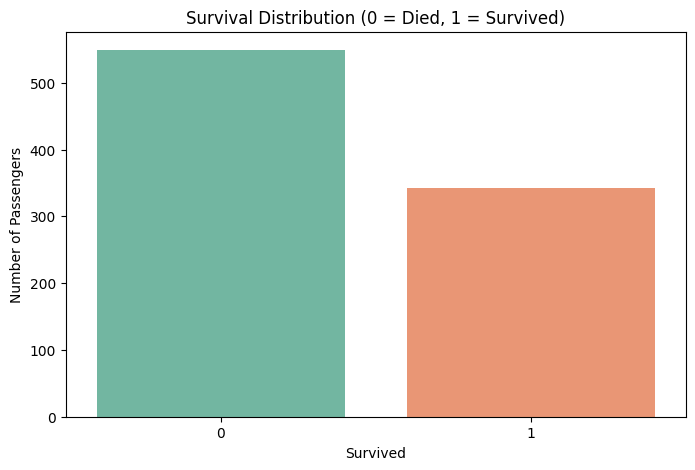

/tmp/ipykernel_799/2375069282.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Pclass', data=df, palette='viridis')


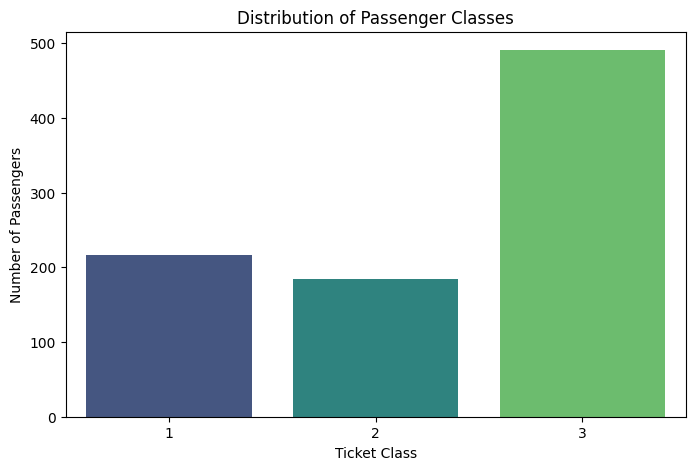

Most common class: 3


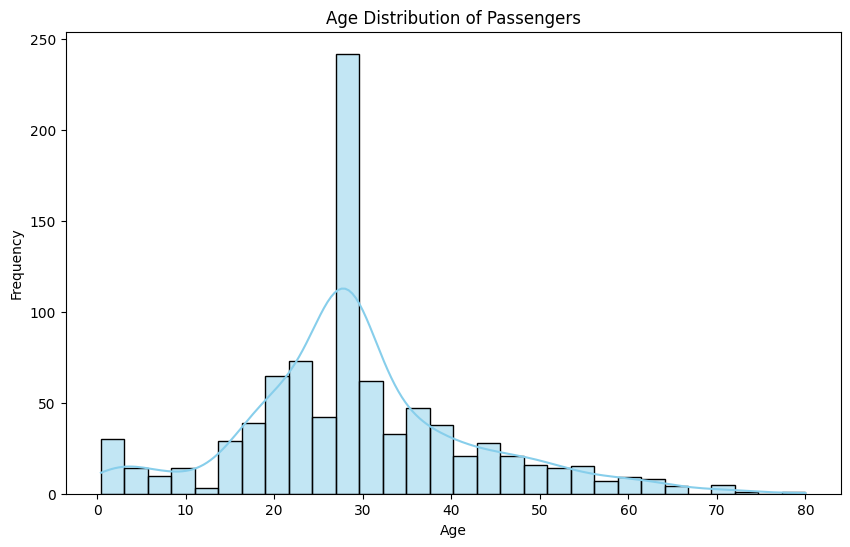

In [8]:
# ========================= TASK 3: Univariate Analysis ========================

# =============
# Survival Rate
# =============
survival_rate = df['Survived'].mean() * 100
print(f"\nOverall Survival Rate: {survival_rate:.2f}%")

# ==============
# Plot: Survived
# ==============
plt.figure(figsize=(8, 5))
sns.countplot(x='Survived', data=df, palette='Set2')
plt.title('Survival Distribution (0 = Died, 1 = Survived)')
plt.ylabel('Number of Passengers')
plt.show()

# =========================
# Plot: Pclass Distribution
# =========================
plt.figure(figsize=(8, 5))
sns.countplot(x='Pclass', data=df, palette='viridis')
plt.title('Distribution of Passenger Classes')
plt.xlabel('Ticket Class')
plt.ylabel('Number of Passengers')
plt.show()

print("Most common class:", df['Pclass'].value_counts().idxmax())

# ======================
# Plot: Age Distribution
# ======================
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=30, kde=True, color='skyblue')
plt.title('Age Distribution of Passengers')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()


/tmp/ipykernel_799/959209882.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=df, palette='mako')


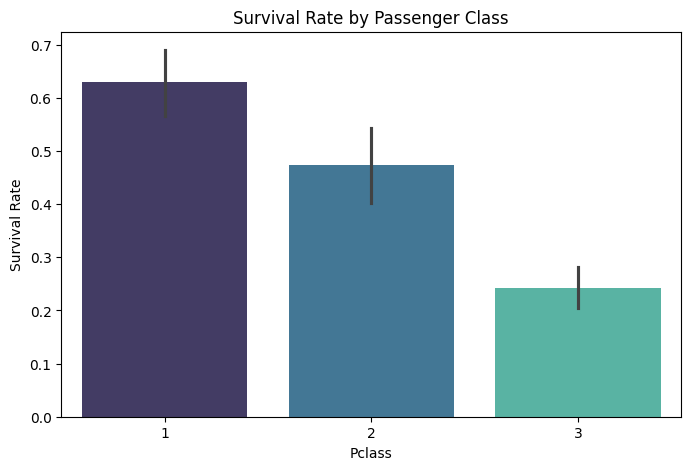


Survival Rate by Class:
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


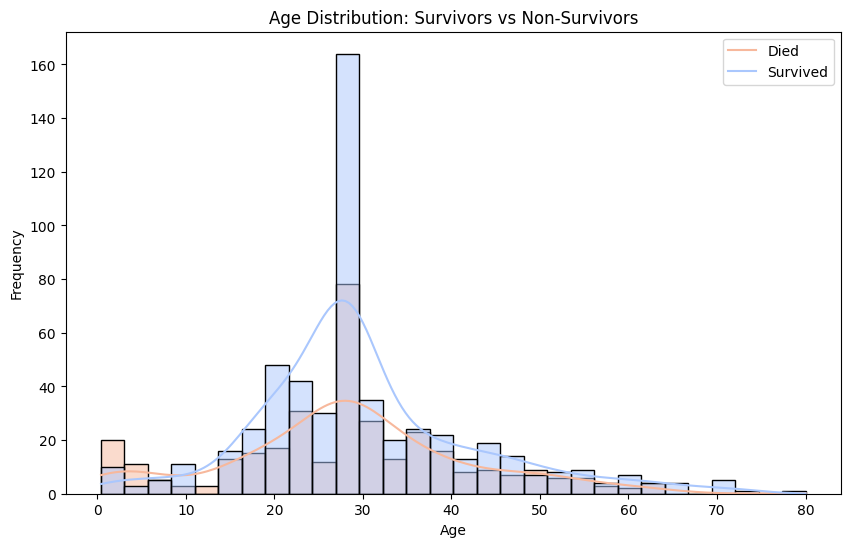

/tmp/ipykernel_799/959209882.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Embarked', y='Survived', data=df, palette='Set1')


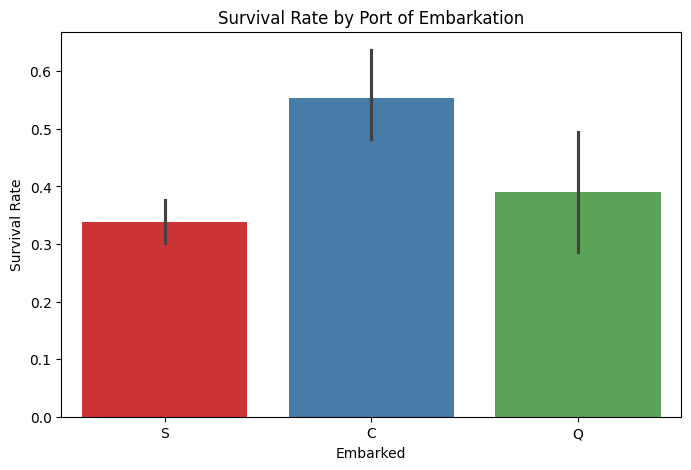


Survival Rate by Embarked Port:
Embarked
C    55.357143
Q    38.961039
S    33.900929
Name: Survived, dtype: float64


In [9]:
# ========================= TASK 4: Bivariate & Multivariate Analysis =========================

# ==================
# Survival by Pclass
# ==================
plt.figure(figsize=(8, 5))
sns.barplot(x='Pclass', y='Survived', data=df, palette='mako')
plt.title('Survival Rate by Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

print("\nSurvival Rate by Class:")
print(df.groupby('Pclass')['Survived'].mean() * 100)

# ==============================
# Survival by Age (Distribution)
# ==============================
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age', hue='Survived', bins=30, kde=True, palette='coolwarm')
plt.title('Age Distribution: Survivors vs Non-Survivors')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.legend(['Died', 'Survived'])
plt.show()

# ====================
# Survival by Embarked
# ====================
plt.figure(figsize=(8, 5))
sns.barplot(x='Embarked', y='Survived', data=df, palette='Set1')
plt.title('Survival Rate by Port of Embarkation')
plt.ylabel('Survival Rate')
plt.show()

print("\nSurvival Rate by Embarked Port:")
print(df.groupby('Embarked')['Survived'].mean() * 100)

In [10]:
# ========================= TASK 5: Conclusion =========================

print("\n" + "="*60)
print("CONCLUSION & KEY INSIGHTS")
print("="*60)
print("""
The analysis shows that survival on the Titanic was heavily influenced by
socio-economic status and demographics.

Top 3 Strongest Predictors of Survival:
1. Passenger Class (Pclass) - Strongest factor
2. Sex (Female passengers had much higher survival)
3. Age (Children had priority)

Key Observations:
- 1st Class passengers had ~63% survival rate vs 24% in 3rd Class.
- Women and children were clearly prioritized ("women and children first").
- Port of embarkation also showed correlation, likely due to class distribution.
""")


CONCLUSION & KEY INSIGHTS

The analysis shows that survival on the Titanic was heavily influenced by 
socio-economic status and demographics.

Top 3 Strongest Predictors of Survival:
1. Passenger Class (Pclass) - Strongest factor
2. Sex (Female passengers had much higher survival)
3. Age (Children had priority)

Key Observations:
- 1st Class passengers had ~63% survival rate vs 24% in 3rd Class.
- Women and children were clearly prioritized ("women and children first").
- Port of embarkation also showed correlation, likely due to class distribution.

